# Data quality and completeness

This notebook reports completeness, missingness, duplicates, data types,
cardinality, and simple distribution checks for the English encoded dataset.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
DATA = Path("../data/processed/en/data.csv")
df = pd.read_csv(DATA, na_values=["NA"])
rows, columns = df.shape
print(f"Rows: {rows:,} | Columns: {columns:,}")
df.head()

Rows: 126 | Columns: 38


,treatment_level_1,age,sex,bmi,baseline_epworth,followup_epworth,overall_score,baseline_symptoms,primary_symptom,sleep_exam_type,...,cardiovascular_comorbidity,endocrine_metabolic_comorbidity,psychiatric_comorbidity,pulmonary_comorbidity,deviated_midline,edge_to_edge_bite,anterior_open_bite,crossbite,class_ii_malocclusion,class_iii_malocclusion
0,0,37,1,21.8,12,10.0,4.00,2,7,0,...,0,0,0,0,1,0,0,0,0,0
1,1,36,1,18.4,11,9.0,4.75,3,2,1,...,0,0,0,0,1,0,0,0,0,0
2,0,71,1,18.7,5,5.0,4.00,8,5,1,...,0,0,0,1,0,0,0,0,0,0
3,0,68,0,19.3,0,0.0,5.00,7,5,1,...,1,1,1,1,1,0,0,1,0,0
4,0,65,1,19.4,5,7.0,4.25,2,4,1,...,1,0,0,0,0,0,0,0,1,0


## Completeness by column


In [2]:
quality = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100),
    "complete_count": df.notna().sum(),
    "unique_non_missing": df.nunique(dropna=True),
})
quality["complete_percent"] = quality["complete_count"].div(rows).mul(100)
quality = quality.sort_values("missing_percent", ascending=False)
quality.round(2)

,missing_count,missing_percent,complete_count,unique_non_missing,complete_percent
elongated_uvula,1,0.79,125,3,99.21
followup_epworth,1,0.79,125,20,99.21
minimum_o2,1,0.79,125,24,99.21
spo2,1,0.79,125,47,99.21
cardiovascular_comorbidity,0,0.00,126,2,100.00
yawn_uvula_movement,0,0.00,126,4,100.00
phonation_soft_palate_movement,0,0.00,126,4,100.00
phonation_uvula_movement,0,0.00,126,4,100.00
chewing_sign,0,0.00,126,2,100.00
swallowing_sign,0,0.00,126,2,100.00


## Missingness map and row completeness


,row_completeness_percent
count,126.00
mean,99.92
std,0.57
min,94.74
25%,100.00
50%,100.00
75%,100.00
max,100.00


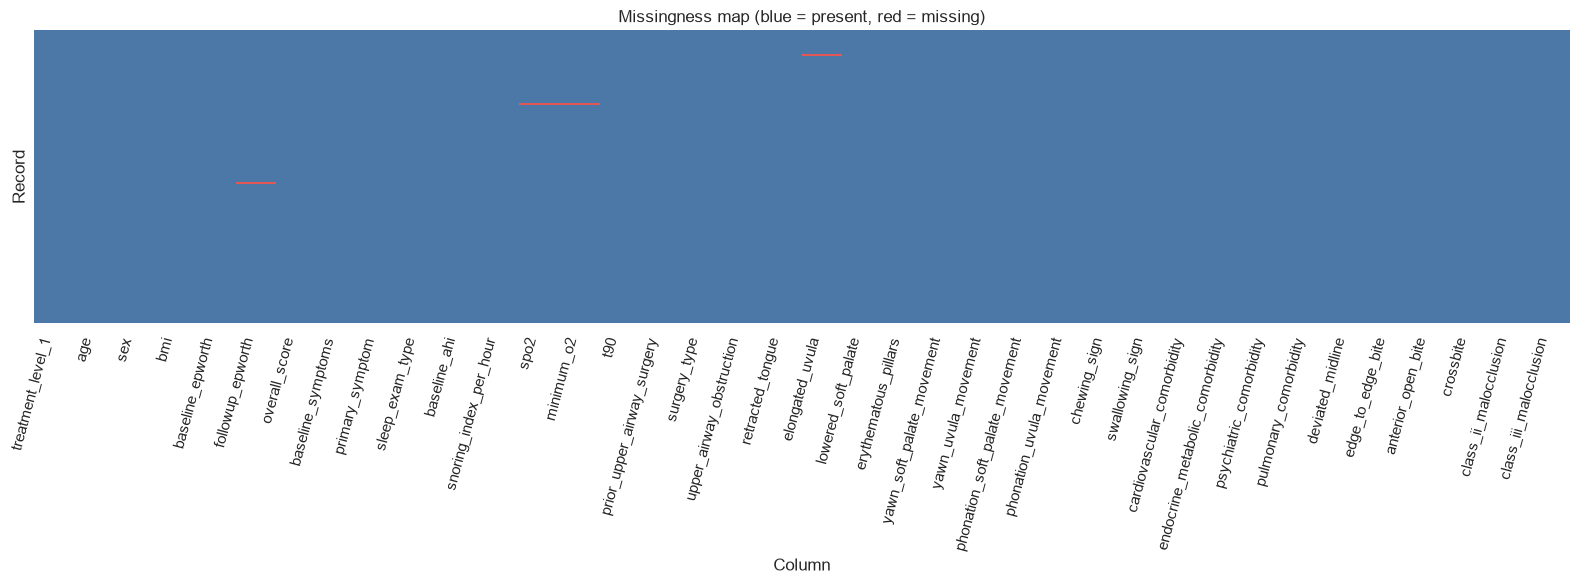

In [4]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, ax=ax, cmap=["#4c78a8", "#e45756"])
ax.set(title="Missingness map (blue = present, red = missing)", xlabel="Column", ylabel="Record")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()

row_completeness = df.notna().mean(axis=1).mul(100)
row_completeness.describe().to_frame("row_completeness_percent").round(2)

## Structural checks


In [5]:
checks = pd.Series({
    "duplicate_rows": int(df.duplicated().sum()),
    "rows_with_any_missing": int(df.isna().any(axis=1).sum()),
    "fully_complete_rows": int(df.notna().all(axis=1).sum()),
    "columns_with_missing": int(df.isna().any(axis=0).sum()),
})
checks

duplicate_rows             0
rows_with_any_missing      3
fully_complete_rows      123
columns_with_missing       4
dtype: int64

In [6]:
type_report = pd.DataFrame({"dtype": df.dtypes.astype(str), "unique_values": df.nunique(dropna=True)})
type_report

,dtype,unique_values
treatment_level_1,int64,2
age,int64,47
sex,int64,2
bmi,float64,89
baseline_epworth,int64,23
followup_epworth,float64,20
overall_score,float64,15
baseline_symptoms,int64,10
primary_symptom,int64,9
sleep_exam_type,int64,2
